In [118]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

# STEP 1: Load Dataset

In [119]:
df = pd.read_csv("heart_disease_prediction.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [121]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [122]:
df.shape

(918, 12)

In [123]:
# check missing values 
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [124]:
# check duplicates 
df.duplicated().sum()
df = df.drop_duplicates()

# Step 2: Data Cleaning

In [125]:
print(df[df["Age"] <=0])

Empty DataFrame
Columns: [Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope, HeartDisease]
Index: []


In [126]:
print(df["RestingBP"].describe())

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64


In [127]:
print(df[df["RestingBP"] <=0])

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
449   55   M           NAP          0            0          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
449    155              N      1.5     Flat             1  


In [128]:
print(df[df["Cholesterol"] <=0])

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
293   65   M           ASY        115            0          0     Normal   
294   32   M            TA         95            0          1     Normal   
295   61   M           ASY        105            0          1     Normal   
296   50   M           ASY        145            0          1     Normal   
297   57   M           ASY        110            0          1         ST   
..   ...  ..           ...        ...          ...        ...        ...   
514   43   M           ASY        122            0          0     Normal   
515   63   M           NAP        130            0          1         ST   
518   48   M           NAP        102            0          1         ST   
535   56   M           ASY        130            0          0        LVH   
536   62   M           NAP        133            0          1         ST   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
293     93              Y  

In [129]:
(df["Cholesterol"] <=0).sum()

172

In [130]:
# it is medically impossible values such a 0 blood pressure and 0 cholestrol 
## since this is likely impossible converting them to missing values using the medians to 
## preserve the dataset while reducing the impact of outliers.

df["Cholesterol"]=df["Cholesterol"].replace(0, pd.NA)
df["RestingBP"] = df["RestingBP"].replace(0, pd.NA)


In [131]:
df["Cholesterol"].median()
df["RestingBP"]=df["RestingBP"].fillna(df["Cholesterol"].median())

/var/folders/r1/j0l8m2nn0_vb3lwftpps9qnh0000gn/T/ipykernel_97413/2595679583.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["RestingBP"]=df["RestingBP"].fillna(df["Cholesterol"].median())


Using median because cholesterol / blood pressure can contain outliers. The mean is sensitive to extreme values and can distort the imputed values, whereas the median provides a more robust estimate of the central tendency.

In [132]:
print(df[df["MaxHR"] <= 0])


Empty DataFrame
Columns: [Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope, HeartDisease]
Index: []


In [133]:
print(df[df["Oldpeak"] < 0])

     Age Sex ChestPainType  RestingBP Cholesterol  FastingBS RestingECG  \
321   63   M           ASY      100.0        <NA>          1     Normal   
324   46   M           ASY      100.0        <NA>          1         ST   
325   42   M           ASY      105.0        <NA>          1     Normal   
326   45   M           NAP      110.0        <NA>          0     Normal   
331   56   M           ASY      115.0        <NA>          1         ST   
332   38   M           NAP      100.0        <NA>          0     Normal   
334   51   M           ASY      130.0        <NA>          1     Normal   
335   62   M            TA      120.0        <NA>          1        LVH   
352   56   M           ASY      120.0        <NA>          0         ST   
407   62   M           ASY      115.0        <NA>          1     Normal   
413   56   M           NAP      125.0        <NA>          1     Normal   
421   66   M           NAP      120.0        <NA>          0         ST   
512   35   M           NA

In [134]:
df["Oldpeak"].describe()

count    918.000000
mean       0.887364
std        1.066570
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

In [135]:
print(df["FastingBS"].unique())

[0 1]


In [136]:
# checking for outliers using IQR method:
def detect_outliers(df, column):
    Q1 =df[column].quantile(0.25)
    Q3 =df[column].quantile(0.75)
    IQR =Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[ (df[column]<lower) | (df[column]>upper) ]
    return outliers

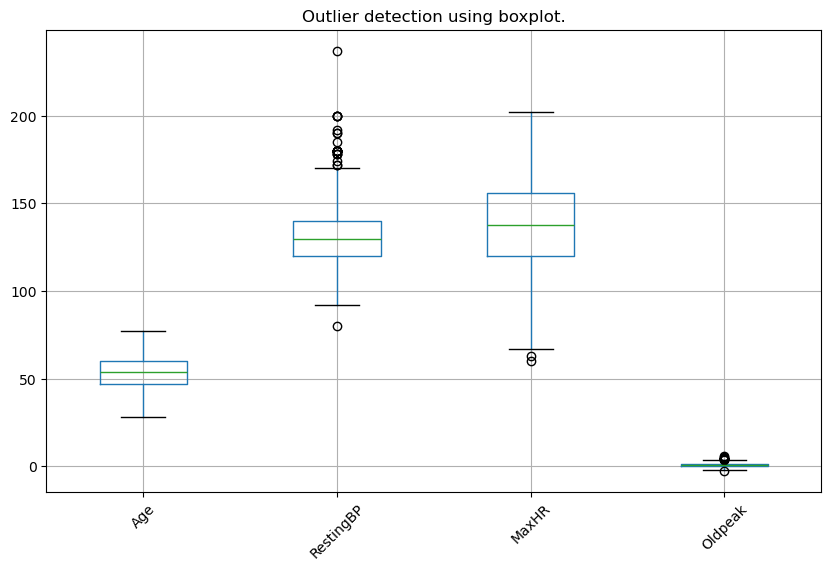

In [137]:
column = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
plt.figure(figsize=(10,6))
df[column].boxplot()

plt.title("Outlier detection using boxplot.")
plt.xticks(rotation=45)
plt.show()

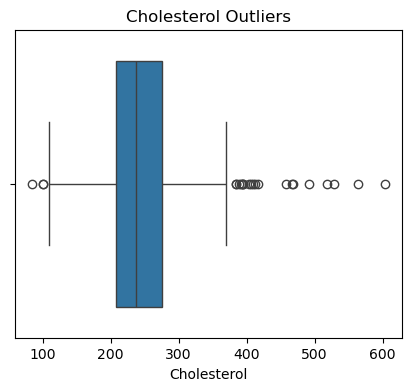

In [138]:
plt.figure(figsize=(5,4))
sns.boxplot(x=df["Cholesterol"])
plt.title("Cholesterol Outliers")
plt.show()

Since the dataset is medical, outliers were retained as they may represent critical pathological conditions. Only invalid values were corrected to preserve clinical meaning.

# Step 3: EDA

In [139]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

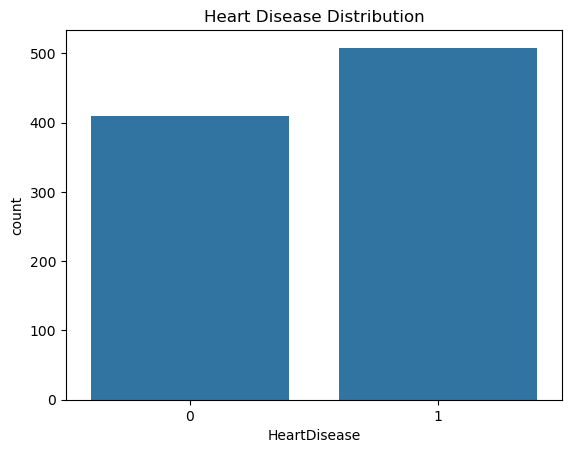

In [140]:
sns.countplot(x=df["HeartDisease"])
plt.title("Heart Disease Distribution")
plt.show()

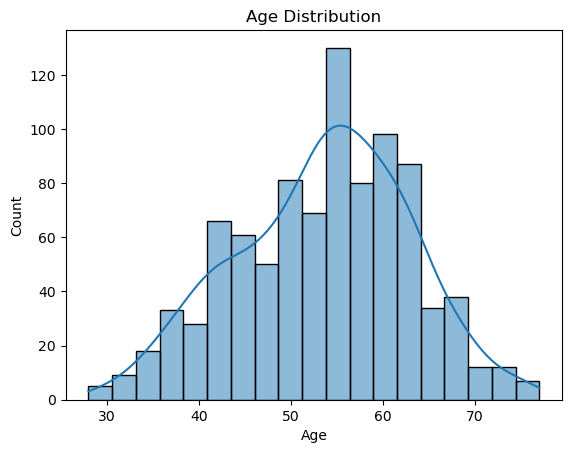

In [141]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

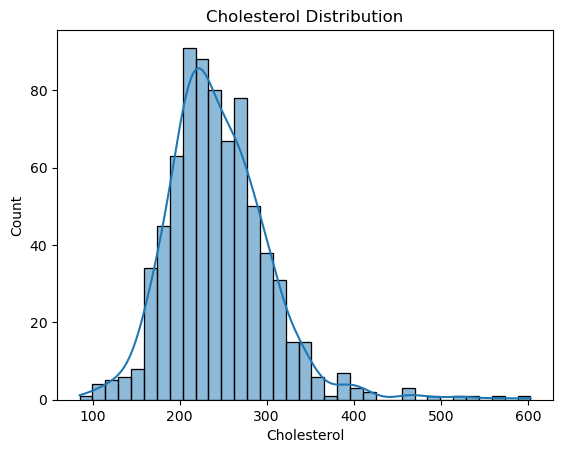

In [142]:
sns.histplot(df["Cholesterol"], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

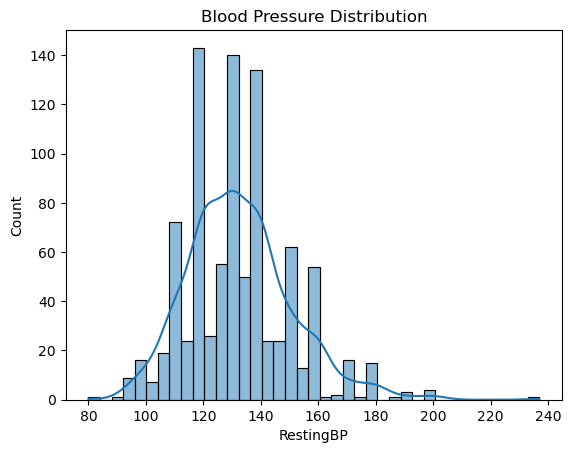

In [143]:
sns.histplot(df["RestingBP"], kde=True)
plt.title("Blood Pressure Distribution")
plt.show()

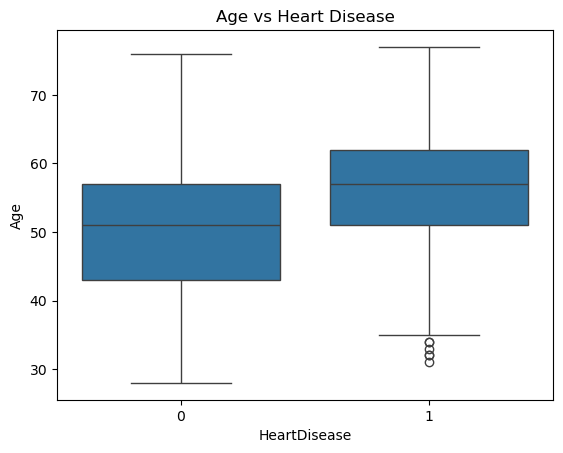

In [144]:
sns.boxplot(x=df["HeartDisease"], y=df["Age"])
plt.title("Age vs Heart Disease")
plt.show()

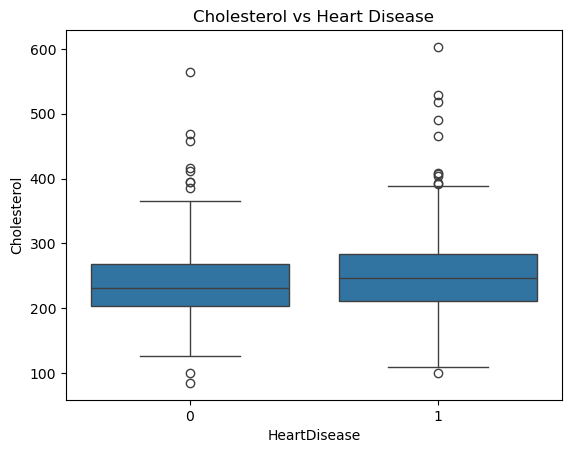

In [145]:
sns.boxplot(x=df["HeartDisease"], y=df["Cholesterol"])
plt.title("Cholesterol vs Heart Disease")
plt.show()

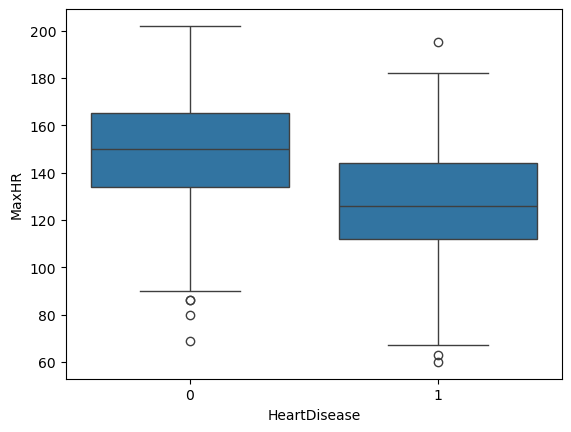

In [146]:
sns.boxplot(x=df["HeartDisease"], y=df["MaxHR"])
plt.show()

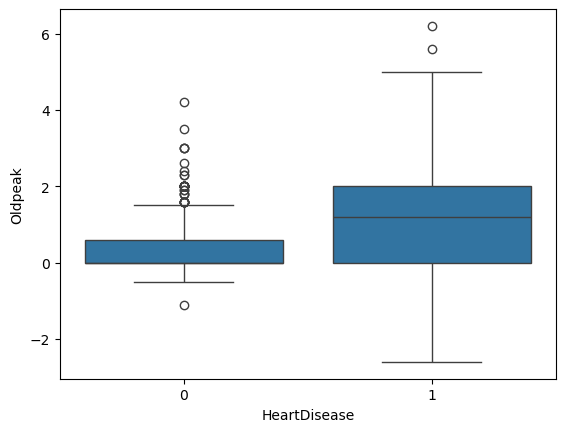

In [147]:
sns.boxplot(x=df["HeartDisease"], y=df["Oldpeak"])
plt.show()

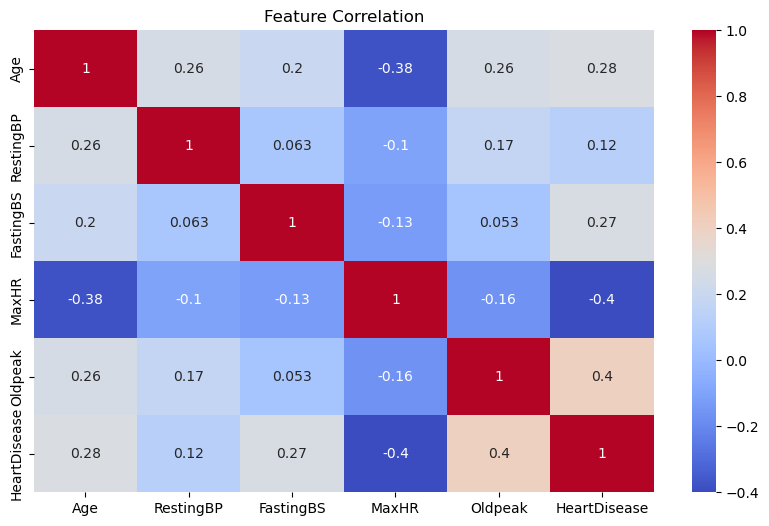

In [148]:
# correlation heatmap
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [152]:
print(df.columns)
print(df.dtypes)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')
Age                 int64
Sex                object
ChestPainType      object
RestingBP         float64
Cholesterol        object
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [153]:
df['Cholesterol'] = pd.to_numeric(df['Cholesterol'], errors='coerce')

In [154]:
print(df.dtypes)

Age                 int64
Sex                object
ChestPainType      object
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [155]:
df['Cholesterol'].fillna(df['Cholesterol'].median(), inplace=True)

/var/folders/r1/j0l8m2nn0_vb3lwftpps9qnh0000gn/T/ipykernel_97413/4131661491.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cholesterol'].fillna(df['Cholesterol'].median(), inplace=True)


In [156]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

df_cat = pd.get_dummies(df[cat_cols], drop_first=True)

df_num = df.drop(columns=cat_cols)

In [157]:
df_clean = pd.concat([df_num, df_cat], axis=1)

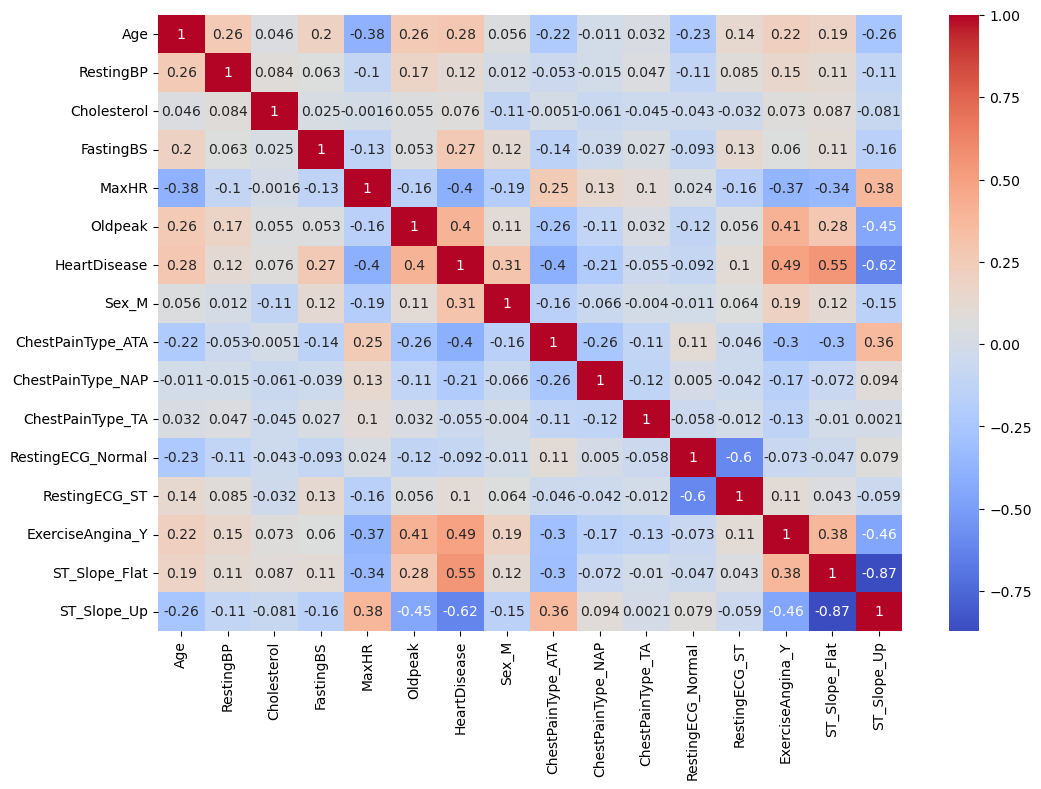

In [159]:

plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), cmap="coolwarm", annot=True)
plt.show()

The heatmap shows that chest pain type, ST slope, and max heart rate have stronger relationships with heart disease, while features like cholesterol and age show weaker but still relevant correlations. Overall, heart disease prediction depends on multiple interacting factors rather than a single dominant feature.

# Step 4: KNN model Building

In [162]:
# splitting train/test sets 
X = df_clean.drop(["HeartDisease"], axis=1)
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=417)

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [163]:
# training model 
knn = KNeighborsClassifier(n_neighbors =5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [165]:
y_pred = knn.predict(X_test)

In [166]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8532608695652174


In [171]:
# confusion matrix:
from sklearn.metrics import classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[74 11]
 [16 83]]
              precision    recall  f1-score   support

           0       0.82      0.87      0.85        85
           1       0.88      0.84      0.86        99

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



The model achieved 85% accuracy. The recall for heart disease patients is 0.84, meaning the model correctly identifies most patients with the condition, though some cases are still missed. In medical problems, recall is more important than accuracy.

# Step 5: Model optimization


In [177]:
scores =[]

for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    pred =knn.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

In [180]:
best_k = scores.index(max(scores)) + 1
best_score =max(scores)

print("Best K:",best_k)
print("Best Accuracy:",best_score)

Best K: 19
Best Accuracy: 0.8913043478260869


In [182]:
# train final model
knn_opt = KNeighborsClassifier(n_neighbors=19)
knn_opt.fit(X_train, y_train)
y_pred_opt = knn_opt.predict(X_test)

In [183]:
accuracy= accuracy_score(y_test, y_pred_opt)
print("Final accuracy:",accuracy)

Final accuracy: 0.8913043478260869


In [185]:
# classification report
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        85
           1       0.90      0.90      0.90        99

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [186]:
#confusion matrix
cm_new = confusion_matrix(y_test, y_pred_opt)
print(cm_new)

[[75 10]
 [10 89]]


To optimize model performance, multiple values of K ranging from 1 to 20 were evaluated. The highest test accuracy was achieved when K = 19.

In [187]:
# roc-auc score
from sklearn.metrics import roc_auc_score
y_prob = knn_opt.predict_proba(X_test)[:,1]
roc_auc =roc_auc_score(y_test, y_prob)
print(roc_auc)

0.9285204991087344


The optimized KNN model achieved a ROC-AUC score of 0.93, demonstrating excellent ability to distinguish between patients with and without heart disease.

# Step 6: Saving the model 


In [188]:
import pickle
pickle.dump(knn_opt, open("heart_model.pkl","wb"))

In [190]:
pickle.dump(scaler, open("scaler.pkl","wb"))

The final optimized KNN model (K=19) was serialized along with the MinMaxScaler to ensure consistent preprocessing during deployment.

In [193]:
# load model and scaler 
model = pickle.load(open("heart_model.pkl","rb"))
scaler=pickle.load(open("scaler.pkl","rb"))

In [200]:
sample = pd.DataFrame(columns=X.columns)

sample.loc[0] = 0

sample.loc[0, "Age"] = 40
sample.loc[0, "RestingBP"] = 120
sample.loc[0, "Cholesterol"] = 200
sample.loc[0, "MaxHR"] = 150
sample.loc[0, "Oldpeak"] = 1.0
sample.loc[0, "FastingBS"] = 0
sample.loc[0, "Sex_M"] = 1
sample.loc[0, "ChestPainType_ATA"] = 1
sample.loc[0, "ST_Slope_Up"] = 1
sample.loc[0, "ExerciseAngina_Y"] = 0

In [201]:
sample_scaled = scaler.transform(sample)

# Step 7 : Predict

In [202]:
prediction = model.predict(sample_scaled)
print(prediction[0])

0


0 → No Heart Disease

In [204]:
# another example: 
sample2 = pd.DataFrame(columns=X.columns)
sample2.loc[0] =0

sample2.loc[0, "Age"] = 65
sample2.loc[0, "RestingBP"] = 150
sample2.loc[0, "Cholesterol"] = 320
sample2.loc[0, "MaxHR"] = 100
sample2.loc[0, "Oldpeak"] = 2.5
sample2.loc[0, "FastingBS"] = 1

sample2.loc[0, "Sex_M"] = 1
sample2.loc[0, "ChestPainType_ATA"] = 0
sample2.loc[0, "ChestPainType_NAP"] = 0
sample2.loc[0, "ST_Slope_Up"] = 0
sample2.loc[0, "ExerciseAngina_Y"] = 1


/var/folders/r1/j0l8m2nn0_vb3lwftpps9qnh0000gn/T/ipykernel_97413/326502178.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sample2.loc[0, "Oldpeak"] = 2.5


In [205]:
sample_scaled = scaler.transform(sample2)

prediction = model.predict(sample_scaled)

print("Prediction:", prediction[0])

Prediction: 1


1 → Heart Disease

In [206]:
pickle.dump(X.columns, open("columns.pkl", "wb"))